# EEG Channel Correlation Analysis

In [27]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import mne
from scipy.stats import pearsonr
from scipy.signal import butter, filtfilt
import warnings
warnings.filterwarnings('ignore')

# Set plotting parameters
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 10
sns.set_style("whitegrid")

print("Libraries imported successfully!")

Libraries imported successfully!


In [28]:
# Load EEG data
edf_file_path = "./Dataset/Infants_data/sub-NORB00001/ses-1/eeg/sub-NORB00001_ses-1_task-EEG_eeg.edf"

# Load the raw EEG data using MNE
raw = mne.io.read_raw_edf(edf_file_path, preload=True, verbose=False)

# Print basic information about the data
print(f"Sampling frequency: {raw.info['sfreq']} Hz")
print(f"Number of channels: {len(raw.ch_names)}")
print(f"Channel names: {raw.ch_names}")
print(f"Recording duration: {raw.times[-1]:.2f} seconds")
print(f"Total samples: {len(raw.times)}")

# Display data info
raw.info

Sampling frequency: 200.0 Hz
Number of channels: 21
Channel names: ['Fp1', 'Fp2', 'F3', 'F4', 'C3', 'C4', 'P3', 'P4', 'O1', 'O2', 'F7', 'F8', 'T3', 'T4', 'T5', 'T6', 'FZ', 'CZ', 'PZ', 'Pg1', 'Pg2']
Recording duration: 714.00 seconds
Total samples: 142800


<Info | 8 non-empty values
 bads: []
 ch_names: Fp1, Fp2, F3, F4, C3, C4, P3, P4, O1, O2, F7, F8, T3, T4, T5, ...
 chs: 21 EEG
 custom_ref_applied: False
 highpass: 0.5 Hz
 lowpass: 30.0 Hz
 meas_date: 2023-01-01 02:00:19 UTC
 nchan: 21
 projs: []
 sfreq: 200.0 Hz
 subject_info: <subject_info | his_id: M>
>

In [29]:
# Data preprocessing and cleaning
print("Original data shape:", raw.get_data().shape)

# 1. Set channel types (all as EEG except reference channels)
raw.set_channel_types({ch: 'eeg' for ch in raw.ch_names if not ch.startswith('Pg')})

# 2. Apply bandpass filter (0.5-30 Hz to remove DC drift and high-frequency noise)
raw_filtered = raw.copy().filter(l_freq=0.5, h_freq=30.0, verbose=False)

# 3. Exclude reference channels (Pg1, Pg2) from analysis
eeg_channels = [ch for ch in raw_filtered.ch_names if not ch.startswith('Pg')]
raw_eeg = raw_filtered.pick_channels(eeg_channels)

print(f"EEG channels for analysis: {raw_eeg.ch_names}")
print(f"Filtered data shape: {raw_eeg.get_data().shape}")

# 4. Get clean EEG data as numpy array
eeg_data = raw_eeg.get_data()  # Shape: (channels, time_points)
channel_names = raw_eeg.ch_names
sfreq = raw_eeg.info['sfreq']

print(f"Final data for correlation analysis:")
print(f"- Channels: {len(channel_names)}")
print(f"- Time points: {eeg_data.shape[1]}")
print(f"- Duration: {eeg_data.shape[1]/sfreq:.1f} seconds")

Original data shape: (21, 142800)
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
EEG channels for analysis: ['Fp1', 'Fp2', 'F3', 'F4', 'C3', 'C4', 'P3', 'P4', 'O1', 'O2', 'F7', 'F8', 'T3', 'T4', 'T5', 'T6', 'FZ', 'CZ', 'PZ']
Filtered data shape: (19, 142800)
Final data for correlation analysis:
- Channels: 19
- Time points: 142800
- Duration: 714.0 seconds


In [30]:
# Build correlation matrix
print("Computing correlation matrix...")

# Transpose data so that rows are time points and columns are channels
# This is required for correlation calculation
eeg_data_transposed = eeg_data.T

# Create DataFrame for easier handling
df_eeg = pd.DataFrame(eeg_data_transposed, columns=channel_names)

# Calculate Pearson correlation matrix
correlation_matrix = df_eeg.corr(method='pearson')

print(f"Correlation matrix shape: {correlation_matrix.shape}")
print(f"Matrix values range: {correlation_matrix.values.min():.3f} to {correlation_matrix.values.max():.3f}")

# Display basic statistics of correlations
corr_values = correlation_matrix.values
# Remove diagonal (self-correlations = 1.0)
off_diagonal = corr_values[~np.eye(corr_values.shape[0], dtype=bool)]

print(f"\nCorrelation statistics (excluding diagonal):")
print(f"Mean correlation: {off_diagonal.mean():.3f}")
print(f"Std correlation: {off_diagonal.std():.3f}")
print(f"Min correlation: {off_diagonal.min():.3f}")
print(f"Max correlation: {off_diagonal.max():.3f}")

# Show first few rows/columns
print("\nFirst 5x5 portion of correlation matrix:")
print(correlation_matrix.iloc[:5, :5].round(3))

Computing correlation matrix...
Correlation matrix shape: (19, 19)
Matrix values range: 0.058 to 1.000

Correlation statistics (excluding diagonal):
Mean correlation: 0.447
Std correlation: 0.243
Min correlation: 0.058
Max correlation: 0.932

First 5x5 portion of correlation matrix:
       Fp1    Fp2     F3     F4     C3
Fp1  1.000  0.932  0.918  0.834  0.657
Fp2  0.932  1.000  0.847  0.908  0.634
F3   0.918  0.847  1.000  0.827  0.754
F4   0.834  0.908  0.827  1.000  0.685
C3   0.657  0.634  0.754  0.685  1.000


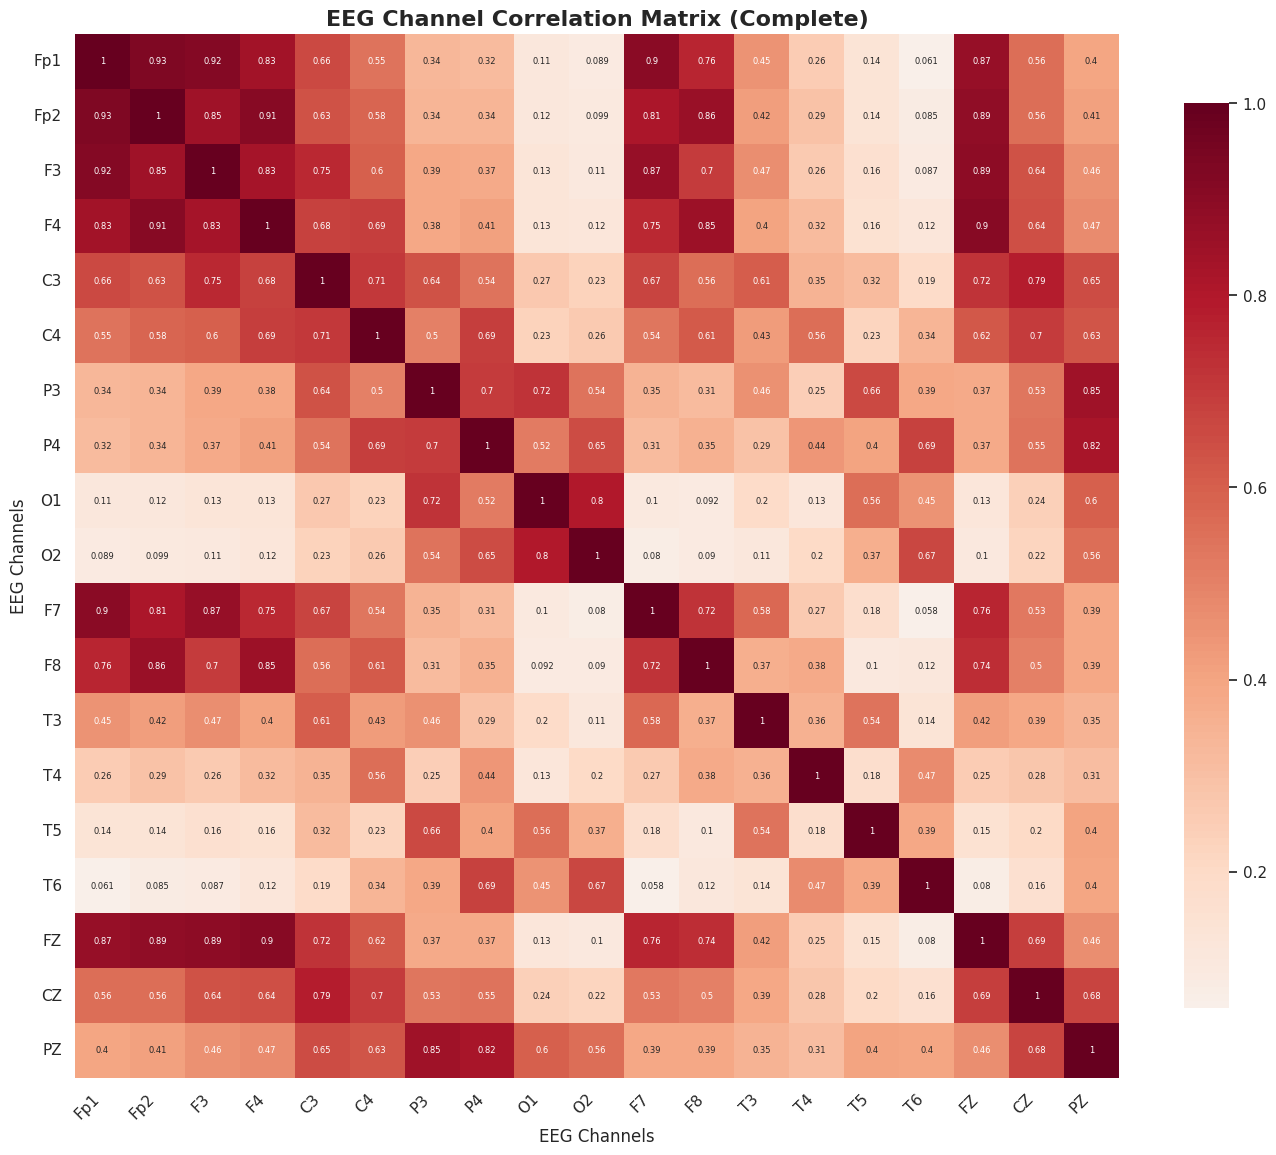

In [31]:
# Visualization 1: Correlation Heatmap
plt.figure(figsize=(14, 12))
sns.heatmap(correlation_matrix, 
            annot=True, 
            cmap='RdBu_r', 
            center=0,
            square=True,
            cbar_kws={"shrink": .8},
            annot_kws={'size': 6})

plt.title('EEG Channel Correlation Matrix (Complete)', fontsize=16, fontweight='bold')
plt.xlabel('EEG Channels', fontsize=12)
plt.ylabel('EEG Channels', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

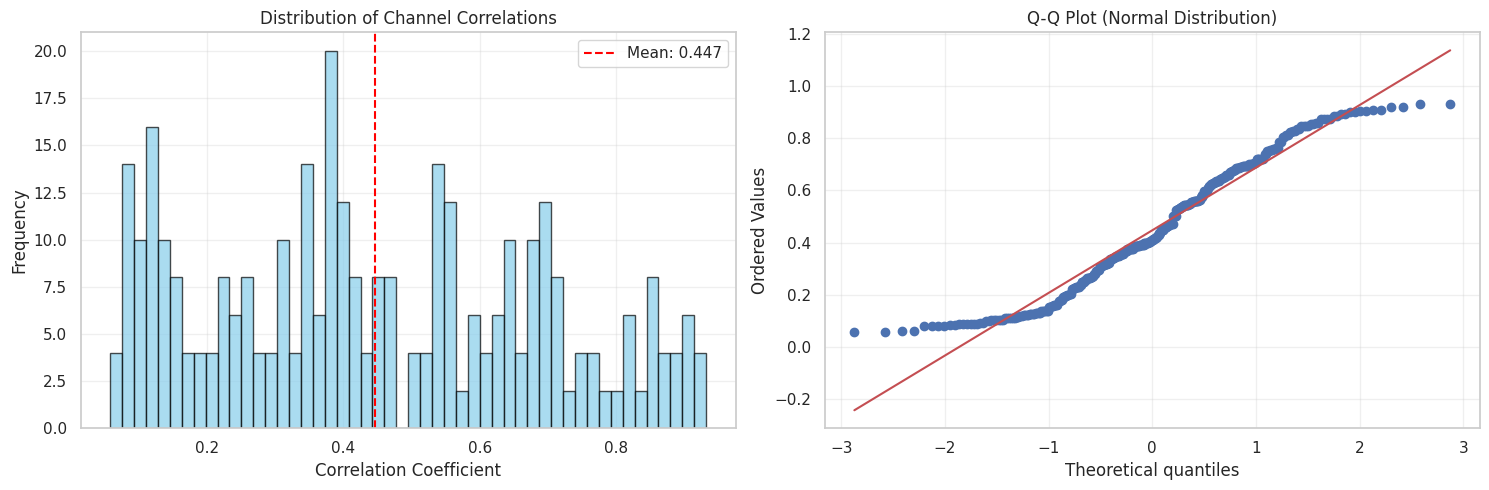

Correlation distribution statistics:
Mean ± Std: 0.447 ± 0.243
Median: 0.410
25th percentile: 0.249
75th percentile: 0.646


In [36]:
# Visualization 2: Distribution of Correlation Values
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Histogram of all correlations (excluding diagonal)
axes[0].hist(off_diagonal, bins=50, alpha=0.7, color='skyblue', edgecolor='black')
axes[0].axvline(off_diagonal.mean(), color='red', linestyle='--', label=f'Mean: {off_diagonal.mean():.3f}')
axes[0].set_title('Distribution of Channel Correlations')
axes[0].set_xlabel('Correlation Coefficient')
axes[0].set_ylabel('Frequency')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# QQ plot to check normality
from scipy import stats
stats.probplot(off_diagonal, dist="norm", plot=axes[1])
axes[1].set_title('Q-Q Plot (Normal Distribution)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print some statistics
print(f"Correlation distribution statistics:")
print(f"Mean ± Std: {off_diagonal.mean():.3f} ± {off_diagonal.std():.3f}")
print(f"Median: {np.median(off_diagonal):.3f}")
print(f"25th percentile: {np.percentile(off_diagonal, 25):.3f}")
print(f"75th percentile: {np.percentile(off_diagonal, 75):.3f}")

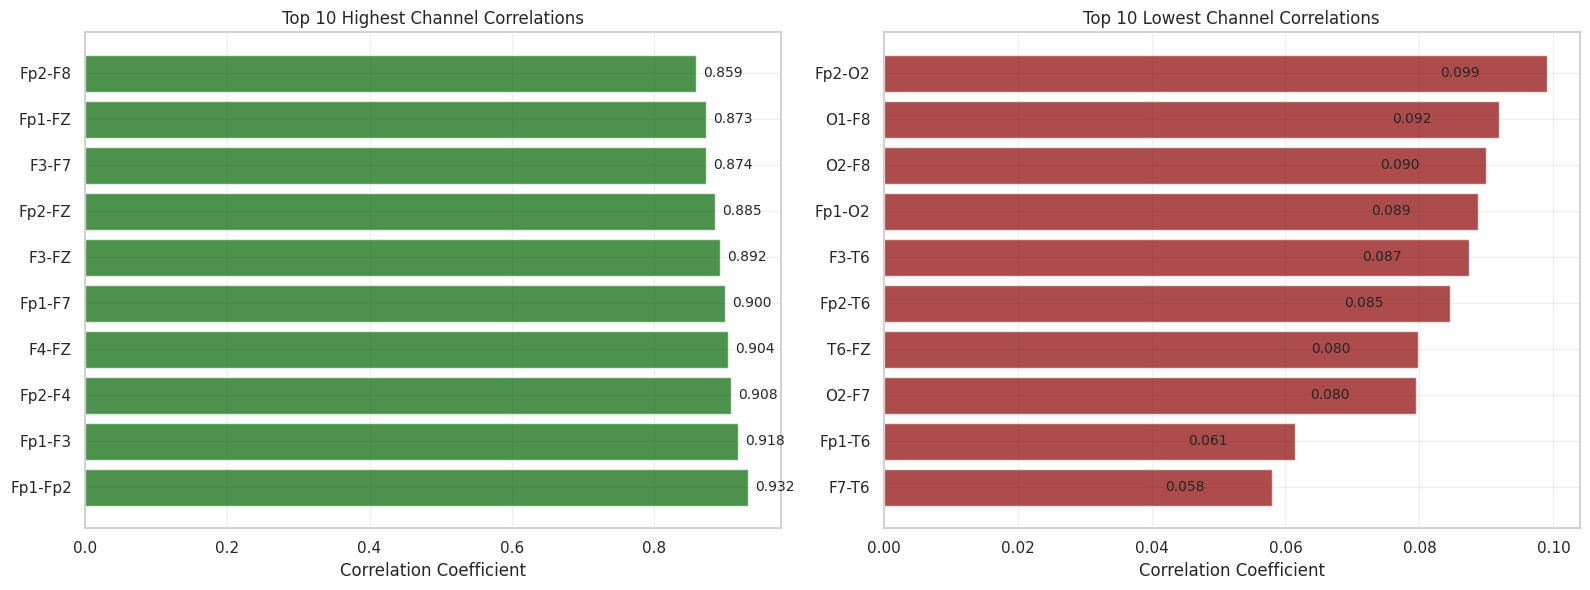

Highest correlations:
Fp1 - Fp2: 0.932
Fp1 - F3: 0.918
Fp2 - F4: 0.908
F4 - FZ: 0.904
Fp1 - F7: 0.900
F3 - FZ: 0.892
Fp2 - FZ: 0.885
F3 - F7: 0.874
Fp1 - FZ: 0.873
Fp2 - F8: 0.859

Lowest correlations:
F7 - T6: 0.058
Fp1 - T6: 0.061
O2 - F7: 0.080
T6 - FZ: 0.080
Fp2 - T6: 0.085
F3 - T6: 0.087
Fp1 - O2: 0.089
O2 - F8: 0.090
O1 - F8: 0.092
Fp2 - O2: 0.099


In [33]:
# Visualization 3: Top and Bottom Correlations Analysis
def get_top_correlations(corr_matrix, n=10):
    """Get top n correlations (excluding self-correlations)"""
    # Get upper triangle indices (excluding diagonal)
    upper_tri = np.triu_indices_from(corr_matrix, k=1)
    correlations = corr_matrix.values[upper_tri]
    
    # Get indices of top correlations
    top_indices = np.argsort(correlations)[-n:][::-1]
    bottom_indices = np.argsort(correlations)[:n]
    
    # Convert back to matrix indices
    top_pairs = [(upper_tri[0][i], upper_tri[1][i]) for i in top_indices]
    bottom_pairs = [(upper_tri[0][i], upper_tri[1][i]) for i in bottom_indices]
    
    return top_pairs, bottom_pairs, correlations[top_indices], correlations[bottom_indices]

# Get top and bottom correlations
top_pairs, bottom_pairs, top_values, bottom_values = get_top_correlations(correlation_matrix, n=10)

# Create visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Top correlations
top_labels = [f"{channel_names[i]}-{channel_names[j]}" for i, j in top_pairs]
axes[0].barh(range(len(top_values)), top_values, color='darkgreen', alpha=0.7)
axes[0].set_yticks(range(len(top_values)))
axes[0].set_yticklabels(top_labels)
axes[0].set_xlabel('Correlation Coefficient')
axes[0].set_title('Top 10 Highest Channel Correlations')
axes[0].grid(True, alpha=0.3)

# Add values on bars
for i, v in enumerate(top_values):
    axes[0].text(v + 0.01, i, f'{v:.3f}', va='center')

# Bottom correlations
bottom_labels = [f"{channel_names[i]}-{channel_names[j]}" for i, j in bottom_pairs]
axes[1].barh(range(len(bottom_values)), bottom_values, color='darkred', alpha=0.7)
axes[1].set_yticks(range(len(bottom_values)))
axes[1].set_yticklabels(bottom_labels)
axes[1].set_xlabel('Correlation Coefficient')
axes[1].set_title('Top 10 Lowest Channel Correlations')
axes[1].grid(True, alpha=0.3)

# Add values on bars
for i, v in enumerate(bottom_values):
    axes[1].text(v - 0.01, i, f'{v:.3f}', va='center', ha='right')

plt.tight_layout()
plt.show()

# Print the results
print("Highest correlations:")
for (i, j), corr in zip(top_pairs, top_values):
    print(f"{channel_names[i]} - {channel_names[j]}: {corr:.3f}")

print("\nLowest correlations:")
for (i, j), corr in zip(bottom_pairs, bottom_values):
    print(f"{channel_names[i]} - {channel_names[j]}: {corr:.3f}")

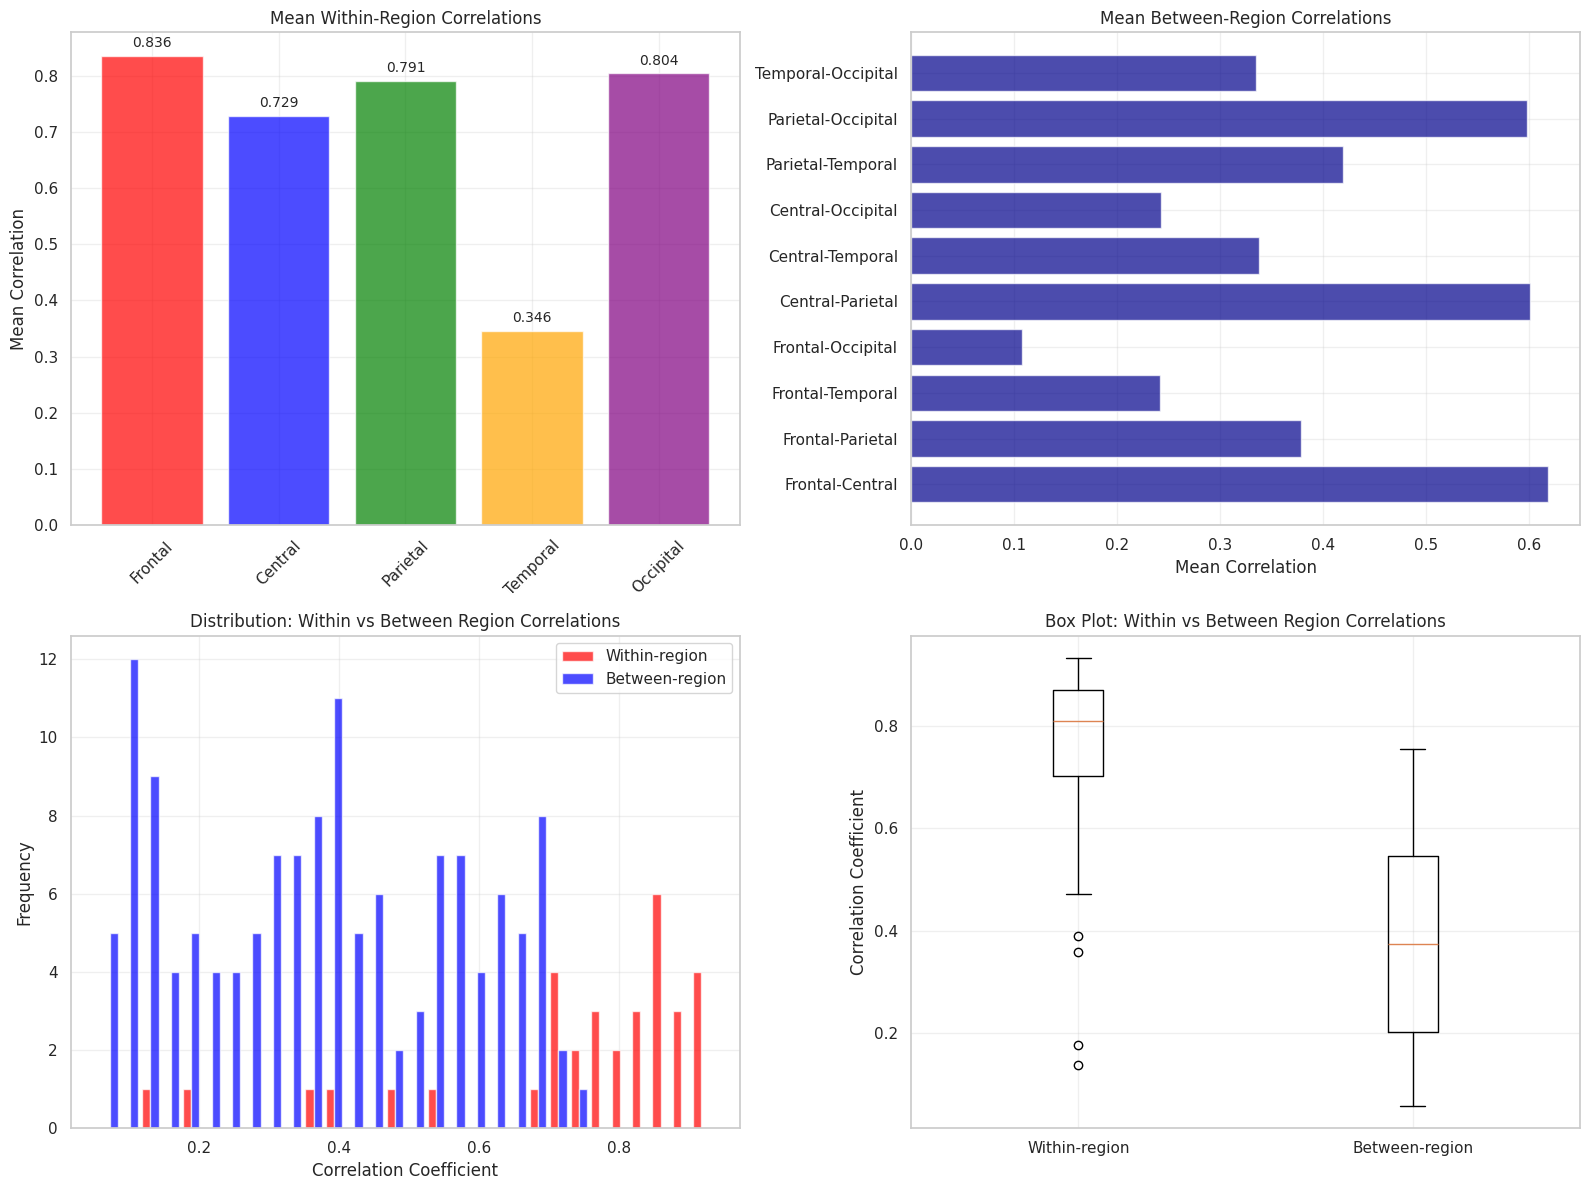

Regional correlation analysis:
Mean within-region correlation: 0.735 ± 0.202
Mean between-region correlation: 0.375 ± 0.194
Difference: 0.360


In [34]:
# Visualization 4: Regional Analysis and Network Visualization
import matplotlib.patches as mpatches

# Define brain regions based on channel names
brain_regions = {
    'Frontal': ['Fp1', 'Fp2', 'F3', 'F4', 'F7', 'F8', 'FZ'],
    'Central': ['C3', 'C4', 'CZ'],
    'Parietal': ['P3', 'P4', 'PZ'],
    'Temporal': ['T3', 'T4', 'T5', 'T6'],
    'Occipital': ['O1', 'O2']
}

# Create region mapping
region_map = {}
for region, channels in brain_regions.items():
    for ch in channels:
        if ch in channel_names:
            region_map[ch] = region

# Calculate within-region and between-region correlations
within_region_corrs = {}
between_region_corrs = {}

for region in brain_regions:
    region_channels = [ch for ch in brain_regions[region] if ch in channel_names]
    if len(region_channels) > 1:
        region_indices = [channel_names.index(ch) for ch in region_channels]
        region_corr_matrix = correlation_matrix.iloc[region_indices, region_indices]
        
        # Get upper triangle excluding diagonal
        mask = np.triu(np.ones_like(region_corr_matrix, dtype=bool), k=1)
        within_region_corrs[region] = region_corr_matrix.values[mask]

# Calculate between-region correlations
region_names = list(brain_regions.keys())
for i, region1 in enumerate(region_names):
    for region2 in region_names[i+1:]:
        channels1 = [ch for ch in brain_regions[region1] if ch in channel_names]
        channels2 = [ch for ch in brain_regions[region2] if ch in channel_names]
        
        if channels1 and channels2:
            indices1 = [channel_names.index(ch) for ch in channels1]
            indices2 = [channel_names.index(ch) for ch in channels2]
            
            between_corrs = []
            for idx1 in indices1:
                for idx2 in indices2:
                    between_corrs.append(correlation_matrix.iloc[idx1, idx2])
            
            between_region_corrs[f"{region1}-{region2}"] = between_corrs

# Visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Within-region correlations
within_means = {region: np.mean(corrs) for region, corrs in within_region_corrs.items()}
regions = list(within_means.keys())
means = list(within_means.values())

axes[0,0].bar(regions, means, color=['red', 'blue', 'green', 'orange', 'purple'][:len(regions)], alpha=0.7)
axes[0,0].set_title('Mean Within-Region Correlations')
axes[0,0].set_ylabel('Mean Correlation')
axes[0,0].tick_params(axis='x', rotation=45)
axes[0,0].grid(True, alpha=0.3)

# Add values on bars
for i, v in enumerate(means):
    axes[0,0].text(i, v + 0.01, f'{v:.3f}', ha='center', va='bottom')

# Between-region correlations
between_means = {pair: np.mean(corrs) for pair, corrs in between_region_corrs.items()}
pairs = list(between_means.keys())
between_vals = list(between_means.values())

axes[0,1].barh(range(len(pairs)), between_vals, color='darkblue', alpha=0.7)
axes[0,1].set_yticks(range(len(pairs)))
axes[0,1].set_yticklabels(pairs)
axes[0,1].set_title('Mean Between-Region Correlations')
axes[0,1].set_xlabel('Mean Correlation')
axes[0,1].grid(True, alpha=0.3)

# Distribution comparison
all_within = np.concatenate(list(within_region_corrs.values()))
all_between = np.concatenate(list(between_region_corrs.values()))

axes[1,0].hist([all_within, all_between], bins=30, alpha=0.7, 
               label=['Within-region', 'Between-region'], color=['red', 'blue'])
axes[1,0].set_title('Distribution: Within vs Between Region Correlations')
axes[1,0].set_xlabel('Correlation Coefficient')
axes[1,0].set_ylabel('Frequency')
axes[1,0].legend()
axes[1,0].grid(True, alpha=0.3)

# Box plot comparison
data_to_plot = [all_within, all_between]
axes[1,1].boxplot(data_to_plot, labels=['Within-region', 'Between-region'])
axes[1,1].set_title('Box Plot: Within vs Between Region Correlations')
axes[1,1].set_ylabel('Correlation Coefficient')
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Regional correlation analysis:")
print(f"Mean within-region correlation: {np.mean(all_within):.3f} ± {np.std(all_within):.3f}")
print(f"Mean between-region correlation: {np.mean(all_between):.3f} ± {np.std(all_between):.3f}")
print(f"Difference: {np.mean(all_within) - np.mean(all_between):.3f}")

In [35]:
# Summary and Final Analysis
print("="*60)
print("EEG CHANNEL CORRELATION ANALYSIS SUMMARY")
print("="*60)

print(f"\nDataset Information:")
print(f"Subject: sub-NORB00001, Session: ses-1")
print(f"Channels analyzed: {len(channel_names)}")
print(f"Recording duration: {eeg_data.shape[1]/sfreq:.1f} seconds")
print(f"Sampling frequency: {sfreq} Hz")

print(f"\nCorrelation Matrix Statistics:")
print(f"Matrix size: {correlation_matrix.shape[0]} × {correlation_matrix.shape[1]}")
print(f"Total channel pairs: {len(off_diagonal)}")
print(f"Mean correlation: {off_diagonal.mean():.3f}")
print(f"Standard deviation: {off_diagonal.std():.3f}")
print(f"Range: [{off_diagonal.min():.3f}, {off_diagonal.max():.3f}]")

print(f"\nKey Findings:")
print(f"1. Highest correlation: {off_diagonal.max():.3f}")
print(f"2. Lowest correlation: {off_diagonal.min():.3f}")
print(f"3. Most correlated pair: {channel_names[top_pairs[0][0]]} - {channel_names[top_pairs[0][1]]}")
print(f"4. Least correlated pair: {channel_names[bottom_pairs[0][0]]} - {channel_names[bottom_pairs[0][1]]}")

if 'all_within' in locals() and 'all_between' in locals():
    print(f"5. Within-region correlations: {np.mean(all_within):.3f} ± {np.std(all_within):.3f}")
    print(f"6. Between-region correlations: {np.mean(all_between):.3f} ± {np.std(all_between):.3f}")

print(f"\nNote: This analysis shows the functional connectivity patterns")
print(f"between EEG channels in resting-state infant brain activity.")

# Display final correlation matrix (rounded for readability)
print(f"\nFinal Correlation Matrix:")
print(correlation_matrix.round(3))

EEG CHANNEL CORRELATION ANALYSIS SUMMARY

Dataset Information:
Subject: sub-NORB00001, Session: ses-1
Channels analyzed: 19
Recording duration: 714.0 seconds
Sampling frequency: 200.0 Hz

Correlation Matrix Statistics:
Matrix size: 19 × 19
Total channel pairs: 342
Mean correlation: 0.447
Standard deviation: 0.243
Range: [0.058, 0.932]

Key Findings:
1. Highest correlation: 0.932
2. Lowest correlation: 0.058
3. Most correlated pair: Fp1 - Fp2
4. Least correlated pair: F7 - T6
5. Within-region correlations: 0.735 ± 0.202
6. Between-region correlations: 0.375 ± 0.194

Note: This analysis shows the functional connectivity patterns
between EEG channels in resting-state infant brain activity.

Final Correlation Matrix:
       Fp1    Fp2     F3     F4     C3     C4     P3     P4     O1     O2  \
Fp1  1.000  0.932  0.918  0.834  0.657  0.545  0.337  0.322  0.113  0.089   
Fp2  0.932  1.000  0.847  0.908  0.634  0.583  0.339  0.339  0.116  0.099   
F3   0.918  0.847  1.000  0.827  0.754  0.599 